In [167]:
import pandas as pd
import numpy as np

In [168]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")

In [169]:
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


In [170]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [171]:
y2 = df_usa_agr_numeric["Crop Yield (MT per HA)"]
X2 = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)","Economic Impact (Million USD)"])

In [172]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

In [173]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    subsample=0.8,
    random_state=42,
    verbose=0
)
 
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
 
print(f"Mean Squared Error: {gb_mse:.4f}")
print(f"Mean Absolute Error: {gb_mae:.4f}")
print(f"R² Score (train): {gb_model.score(X_train, y_train):.4f}")
print(f"R² Score (test): {gb_model.score(X_test, y_test):.4f}")
 
# Show feature importance
feature_importance = gb_model.feature_importances_
top_features = np.argsort(feature_importance)[-5:]
print(f"\nTop 5 most important features (indices): {top_features[::-1]}")
print(f"Importance scores: {feature_importance[top_features[::-1]]}")

Mean Squared Error: 0.7452
Mean Absolute Error: 0.7362
R² Score (train): 0.5665
R² Score (test): 0.2020

Top 5 most important features (indices): [0 1 3 4 2]
Importance scores: [0.53939873 0.15655637 0.14366625 0.11575048 0.04462818]


In [174]:
n_estimators_range = range(1, 101, 1)
train_errors = []
test_errors = []
 
for n in n_estimators_range:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))
 
print(f"Error with 1 tree: {test_errors[0]:.4f}")
print(f"Error with 50 trees: {test_errors[49]:.4f}")
print(f"Error with 100 trees: {test_errors[99]:.4f}")
print(f"Improvement: {(test_errors[0] - test_errors[99]):.4f} ({100*(test_errors[0] - test_errors[99])/test_errors[0]:.1f}%)")

Error with 1 tree: 0.8871
Error with 50 trees: 0.7509
Error with 100 trees: 0.7747
Improvement: 0.1124 (12.7%)


In [175]:
print("\nEffect of learning_rate:")
for lr in [0.001, 0.01, 0.1, 0.5]:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    test_error = mean_squared_error(y_test, model.predict(X_test))
    print(f"  learning_rate={lr:5.3f} → MSE={test_error:10.4f}")
 
print("\nEffect of max_depth:")
for depth in [1, 2, 3, 5, 8, 10]:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    test_error = mean_squared_error(y_test, model.predict(X_test))
    print(f"  max_depth={depth:2d} → MSE={test_error:10.4f}")


Effect of learning_rate:
  learning_rate=0.001 → MSE=    0.8889
  learning_rate=0.010 → MSE=    0.7459
  learning_rate=0.100 → MSE=    0.7747
  learning_rate=0.500 → MSE=    0.9435

Effect of max_depth:
  max_depth= 1 → MSE=    0.7300
  max_depth= 2 → MSE=    0.7459
  max_depth= 3 → MSE=    0.7747
  max_depth= 5 → MSE=    0.7829
  max_depth= 8 → MSE=    0.8311
  max_depth=10 → MSE=    0.8458


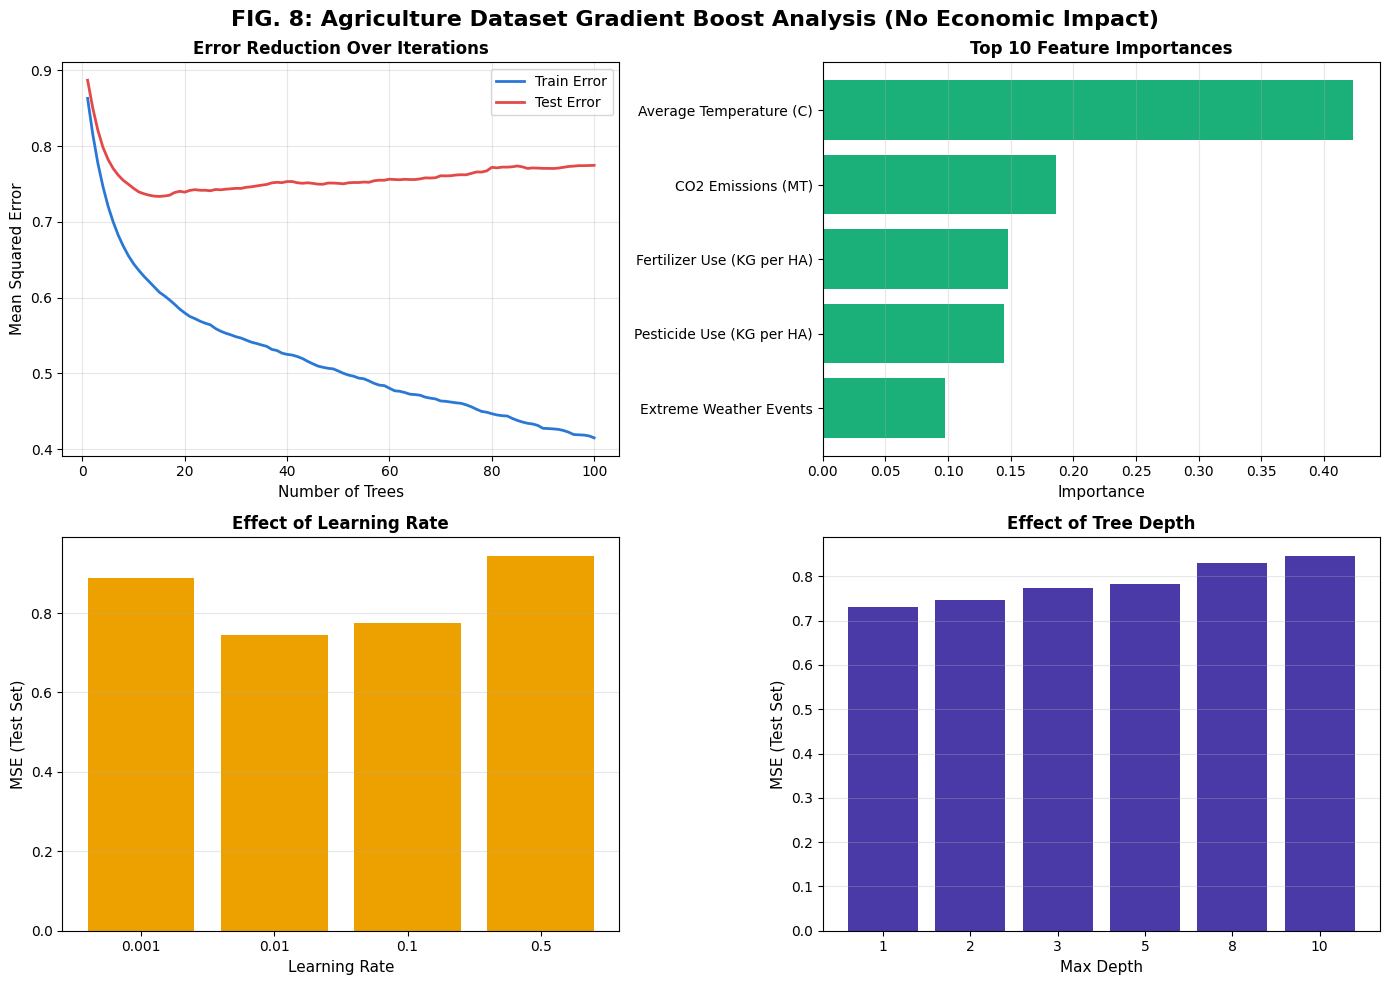

In [176]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
fig.suptitle('FIG. 8: Agriculture Dataset Gradient Boost Analysis (No Economic Impact)', fontsize=16, fontweight='bold')

# Plot 1: Error reduction over iterations
ax1 = axes[0, 0]
ax1.plot(n_estimators_range, train_errors, label='Train Error', linewidth=2, color='#2a78d6')
ax1.plot(n_estimators_range, test_errors, label='Test Error', linewidth=2, color='#e34948')
ax1.set_xlabel('Number of Trees', fontsize=11)
ax1.set_ylabel('Mean Squared Error', fontsize=11)
ax1.set_title('Error Reduction Over Iterations', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Feature importance

ax2 = axes[0, 1]
feature_importance = model.feature_importances_
feature_names = X2.columns

top_idx = np.argsort(feature_importance)[-10:]

ax2.barh(range(len(top_idx)), feature_importance[top_idx], color='#1baf7a')
ax2.set_yticks(range(len(top_idx)))
ax2.set_yticklabels(feature_names[top_idx])
top_idx = np.argsort(feature_importance)[-10:]
ax2.barh(range(len(top_idx)), feature_importance[top_idx], color='#1baf7a')
ax2.set_yticks(range(len(top_idx)))
ax2.set_xlabel('Importance', fontsize=11)
ax2.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
 
# Plot 3: Learning rate comparison
ax3 = axes[1, 0]
learning_rates = [0.001, 0.01, 0.1, 0.5]
lr_errors = []
for lr in learning_rates:
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    lr_errors.append(mean_squared_error(y_test, model.predict(X_test)))
 
ax3.bar(range(len(learning_rates)), lr_errors, color='#eda100')
ax3.set_xticks(range(len(learning_rates)))
ax3.set_xticklabels(learning_rates)
ax3.set_xlabel('Learning Rate', fontsize=11)
ax3.set_ylabel('MSE (Test Set)', fontsize=11)
ax3.set_title('Effect of Learning Rate', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
 
# Plot 4: Max depth comparison
ax4 = axes[1, 1]
depths = [1, 2, 3, 5, 8, 10]
depth_errors = []
for d in depths:
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    depth_errors.append(mean_squared_error(y_test, model.predict(X_test)))
 
ax4.bar(range(len(depths)), depth_errors, color='#4a3aa7')
ax4.set_xticks(range(len(depths)))
ax4.set_xticklabels(depths)
ax4.set_xlabel('Max Depth', fontsize=11)
ax4.set_ylabel('MSE (Test Set)', fontsize=11)
ax4.set_title('Effect of Tree Depth', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

In [177]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=1,
    min_samples_split=5,
    subsample=0.8,
    random_state=42,
    verbose=0
)
 
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
 
print(f"Mean Squared Error: {gb_mse:.4f}")
print(f"Mean Absolute Error: {gb_mae:.4f}")
print(f"R² Score (train): {gb_model.score(X_train, y_train):.4f}")
print(f"R² Score (test): {gb_model.score(X_test, y_test):.4f}")


Mean Squared Error: 0.8099
Mean Absolute Error: 0.7651
R² Score (train): 0.1821
R² Score (test): 0.1327


In [178]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


In [179]:
y1 = clean_numeric_dfCO2["temperature_change_from_co2"]
X1 = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])

In [180]:
X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

In [181]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    subsample=0.8,
    random_state=42,
    verbose=0
)
 
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
 
print(f"Mean Squared Error: {gb_mse:.4f}")
print(f"Mean Absolute Error: {gb_mae:.4f}")
print(f"R² Score (train): {gb_model.score(X_train, y_train):.4f}")
print(f"R² Score (test): {gb_model.score(X_test, y_test):.4f}")
 
# Show feature importance
feature_importance = gb_model.feature_importances_
top_features = np.argsort(feature_importance)[-5:]
print(f"\nTop 5 most important features (indices): {top_features[::-1]}")
print(f"Importance scores: {feature_importance[top_features[::-1]]}")

Mean Squared Error: 0.0011
Mean Absolute Error: 0.0051
R² Score (train): 0.9988
R² Score (test): 0.7773

Top 5 most important features (indices): [0 2 3 1]
Importance scores: [9.83057964e-01 1.00703483e-02 6.55160711e-03 3.20080987e-04]


In [182]:
n_estimators_range = range(1, 101, 1)
train_errors = []
test_errors = []
 
for n in n_estimators_range:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))
 
print(f"Error with 1 tree: {test_errors[0]:.4f}")
print(f"Error with 50 trees: {test_errors[49]:.4f}")
print(f"Error with 100 trees: {test_errors[99]:.4f}")
print(f"Improvement: {(test_errors[0] - test_errors[99]):.4f} ({100*(test_errors[0] - test_errors[99])/test_errors[0]:.1f}%)")

Error with 1 tree: 0.0043
Error with 50 trees: 0.0012
Error with 100 trees: 0.0012
Improvement: 0.0030 (71.1%)


In [183]:
print("\nEffect of learning_rate:")
for lr in [0.001, 0.01, 0.1, 0.5]:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    test_error = mean_squared_error(y_test, model.predict(X_test))
    print(f"  learning_rate={lr:5.3f} → MSE={test_error:10.4f}")
 
print("\nEffect of max_depth:")
for depth in [1, 2, 3, 5, 8, 10]:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    test_error = mean_squared_error(y_test, model.predict(X_test))
    print(f"  max_depth={depth:2d} → MSE={test_error:10.4f}")


Effect of learning_rate:
  learning_rate=0.001 → MSE=    0.0043
  learning_rate=0.010 → MSE=    0.0016
  learning_rate=0.100 → MSE=    0.0012
  learning_rate=0.500 → MSE=    0.0013

Effect of max_depth:
  max_depth= 1 → MSE=    0.0011
  max_depth= 2 → MSE=    0.0012
  max_depth= 3 → MSE=    0.0012
  max_depth= 5 → MSE=    0.0012
  max_depth= 8 → MSE=    0.0012
  max_depth=10 → MSE=    0.0012


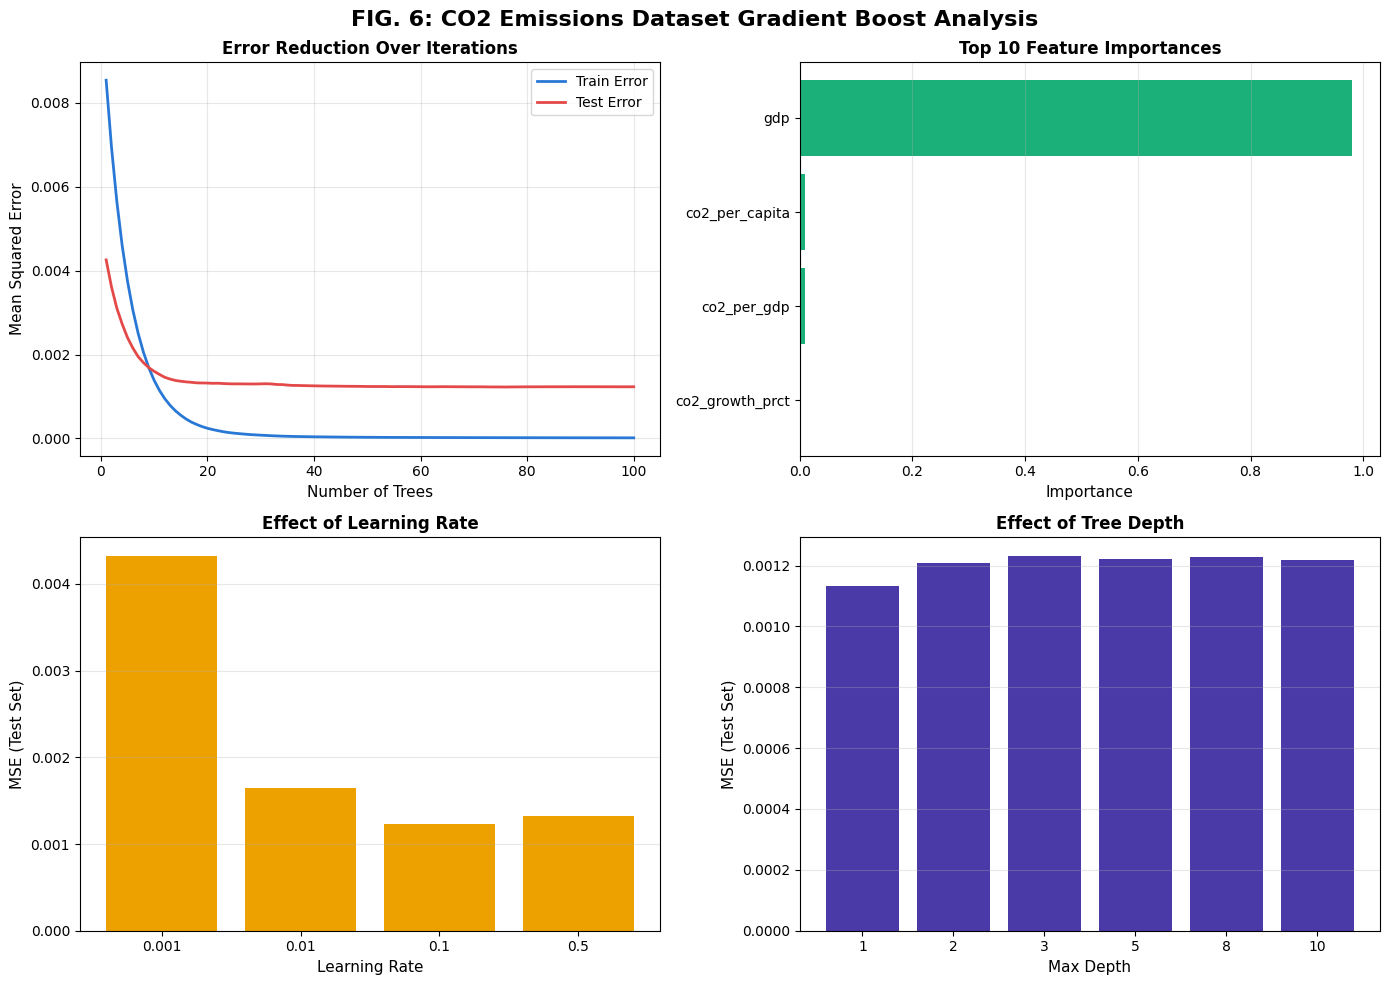

In [184]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
fig.suptitle('FIG. 6: CO2 Emissions Dataset Gradient Boost Analysis', fontsize=16, fontweight='bold')

# Plot 1: Error reduction over iterations
ax1 = axes[0, 0]
ax1.plot(n_estimators_range, train_errors, label='Train Error', linewidth=2, color='#2a78d6')
ax1.plot(n_estimators_range, test_errors, label='Test Error', linewidth=2, color='#e34948')
ax1.set_xlabel('Number of Trees', fontsize=11)
ax1.set_ylabel('Mean Squared Error', fontsize=11)
ax1.set_title('Error Reduction Over Iterations', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
 
# Plot 2: Feature importance
ax2 = axes[0, 1]
feature_importance = model.feature_importances_
feature_names = X1.columns

top_idx = np.argsort(feature_importance)[-10:]

ax2.barh(range(len(top_idx)), feature_importance[top_idx], color='#1baf7a')
ax2.set_yticks(range(len(top_idx)))
ax2.set_yticklabels(feature_names[top_idx])
top_idx = np.argsort(feature_importance)[-10:]
ax2.barh(range(len(top_idx)), feature_importance[top_idx], color='#1baf7a')
ax2.set_yticks(range(len(top_idx)))
ax2.set_xlabel('Importance', fontsize=11)
ax2.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
 
# Plot 3: Learning rate comparison
ax3 = axes[1, 0]
learning_rates = [0.001, 0.01, 0.1, 0.5]
lr_errors = []
for lr in learning_rates:
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    lr_errors.append(mean_squared_error(y_test, model.predict(X_test)))
 
ax3.bar(range(len(learning_rates)), lr_errors, color='#eda100')
ax3.set_xticks(range(len(learning_rates)))
ax3.set_xticklabels(learning_rates)
ax3.set_xlabel('Learning Rate', fontsize=11)
ax3.set_ylabel('MSE (Test Set)', fontsize=11)
ax3.set_title('Effect of Learning Rate', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
 
# Plot 4: Max depth comparison
ax4 = axes[1, 1]
depths = [1, 2, 3, 5, 8, 10]
depth_errors = []
for d in depths:
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    depth_errors.append(mean_squared_error(y_test, model.predict(X_test)))
 
ax4.bar(range(len(depths)), depth_errors, color='#4a3aa7')
ax4.set_xticks(range(len(depths)))
ax4.set_xticklabels(depths)
ax4.set_xlabel('Max Depth', fontsize=11)
ax4.set_ylabel('MSE (Test Set)', fontsize=11)
ax4.set_title('Effect of Tree Depth', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

In [185]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=1,
    min_samples_split=5,
    subsample=0.8,
    random_state=42,
    verbose=0
)
 
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
 
print(f"Mean Squared Error: {gb_mse:.4f}")
print(f"Mean Absolute Error: {gb_mae:.4f}")
print(f"R² Score (train): {gb_model.score(X_train, y_train):.4f}")
print(f"R² Score (test): {gb_model.score(X_test, y_test):.4f}")

Mean Squared Error: 0.0011
Mean Absolute Error: 0.0088
R² Score (train): 0.9865
R² Score (test): 0.7898
